In [ ]:
# Data-path configuration (see ../paths.py and ../DATA.md).
# Set the SCREAM_AUTOTUNE_DATA env var to point at the unpacked Zenodo
# data deposit; defaults to <repo>/data. Assumes this notebook is run
# from its own directory (the Jupyter default).
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


In [1]:
import os.path
import matplotlib
from matplotlib import cm
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.special import gamma
import glob
#from scipy import stats
import shutil
from scipy import interpolate
import matplotlib.tri as tri
import cartopy.crs as ccrs
from mpl_toolkits.basemap import Basemap
from scipy.ndimage import gaussian_filter
#import xcdat

ERA 5 variables
cc - cloud cover
r - relative humidity
w - omega
vo - vorticity
q - water vapor
v - meridonial wind (V in SCREAM)
u - zonal wind

pressure levels might be in pascals for ERA5 and hectopascals for SCREAM

(vertical is fine but horizontal is not, Hassan sent example in slack)

/tmp/ipykernel_784037/132894008.py:31: RuntimeWarning: Mean of empty slice
  T_scream_rgr[i,:] = np.nanmean(T_scream[0,I,:],(0))
/tmp/ipykernel_784037/132894008.py:32: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


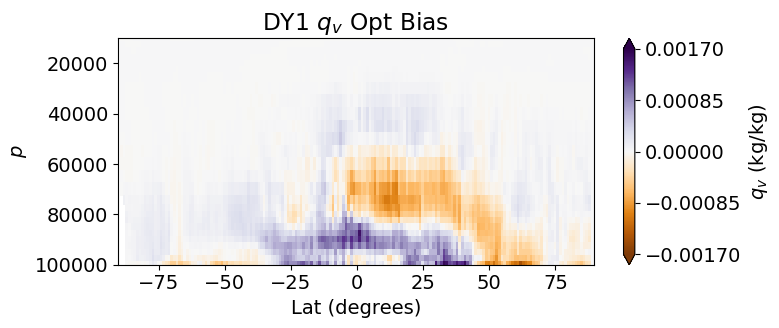

In [61]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
sim_dir = str(paths.DY1_OPTIMAL_RUN_DIR) + '/'
obs_file = 'DY1_era5_qv_ne30pg2.nc'
sim_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_sim = xr.open_mfdataset(sim_dir+sim_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream = ds_sim['qv'].values
T_obs = ds_obs['Q'].values


lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
#vmax = np.nanmax(np.abs(T_scream_rgr - T_obs_rgr))
vmax = np.nanpercentile(np.abs(T_scream_rgr - T_obs_rgr), 10)

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_rgr[i,:] = np.nanmean(T_scream[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp,T_scream_rgr-T_obs_rgr,cmap='PuOr')
#plt.clim(-vmax, vmax)
plt.clim(-0.0017, 0.0017)
plt.title(r'DY1 $q_v$ Opt Bias')

clb = plt.colorbar(extend='both')
clb.set_label(r'$q_v$ (kg/kg)')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
#clb.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY1qv_optobs_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

/tmp/ipykernel_784037/4106260449.py:30: RuntimeWarning: Mean of empty slice
  T_scream_rgr[i,:] = np.nanmean(T_scream[0,I,:],(0))
/tmp/ipykernel_784037/4106260449.py:31: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


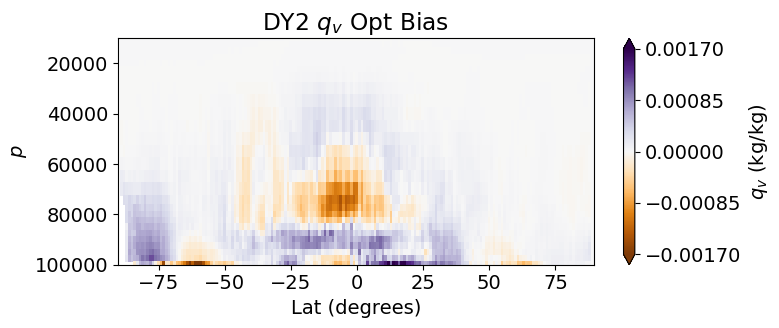

In [63]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
sim_dir = str(paths.DY2_OPTIMAL_RUN_DIR) + '/'
obs_file = 'DY2_era5_qv_ne30pg2.nc'
sim_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_sim = xr.open_mfdataset(sim_dir+sim_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream = ds_sim['qv'].values
T_obs = ds_obs['Q'].values


lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_rgr[i,:] = np.nanmean(T_scream[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp,T_scream_rgr-T_obs_rgr,cmap='PuOr')
#plt.clim(-5,5)
plt.clim(-0.0017, 0.0017)
plt.title(r'DY2 $q_v$ Opt Bias')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_v$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY2qv_optobs_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

/tmp/ipykernel_784037/2318435564.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/2318435564.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
/tmp/ipykernel_784037/2318435564.py:35: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


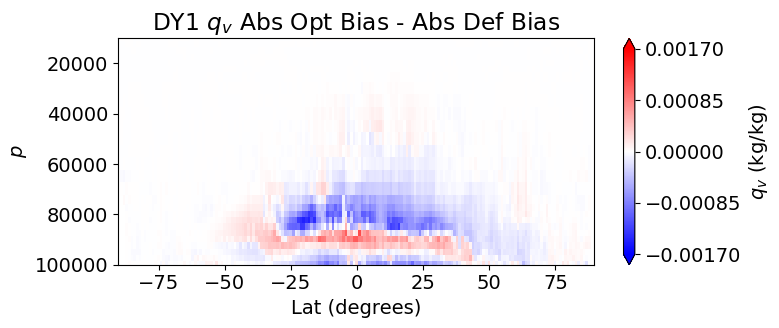

In [64]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY1_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY1_DEFAULT_RUN_DIR) + '/'
obs_file = 'DY1_era5_qv_ne30pg2.nc'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qv'].values
T_scream_def = ds_def['qv'].values
T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, (abs(T_scream_opt_rgr-T_obs_rgr)-abs(T_scream_def_rgr-T_obs_rgr)) ,cmap='bwr')
#plt.clim(-5,5)
plt.clim(-0.0017, 0.0017)
plt.title(r'DY1 $q_v$ Abs Opt Bias - Abs Def Bias')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_v$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY1qv_doublebias_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

/tmp/ipykernel_784037/1526455453.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/1526455453.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
/tmp/ipykernel_784037/1526455453.py:35: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


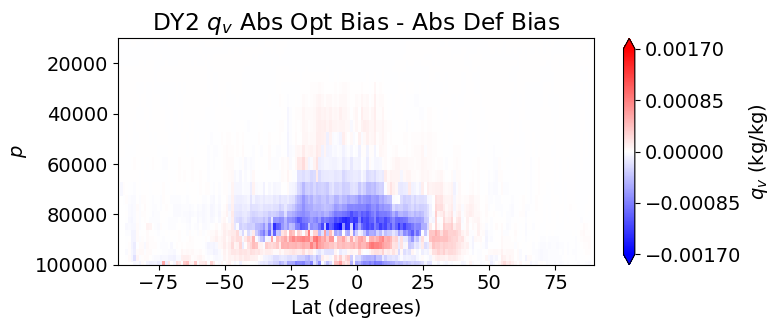

In [65]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY2_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY2_DEFAULT_RUN_DIR) + '/'
obs_file = 'DY2_era5_qv_ne30pg2.nc'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qv'].values
T_scream_def = ds_def['qv'].values
T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, (abs(T_scream_opt_rgr-T_obs_rgr)-abs(T_scream_def_rgr-T_obs_rgr)) ,cmap='bwr')
#plt.clim(-5,5)
plt.clim(-0.0017, 0.0017)
plt.title(r'DY2 $q_v$ Abs Opt Bias - Abs Def Bias')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_v$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY2qv_doublebias_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

/tmp/ipykernel_784037/4090062817.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/4090062817.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
/tmp/ipykernel_784037/4090062817.py:35: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


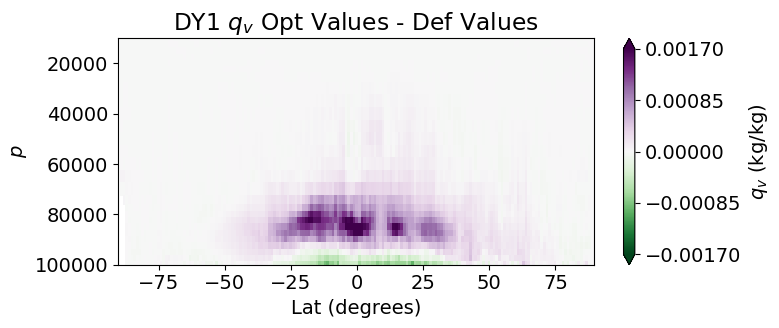

In [66]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY1_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY1_DEFAULT_RUN_DIR) + '/'
obs_file = 'DY1_era5_qv_ne30pg2.nc'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qv'].values
T_scream_def = ds_def['qv'].values
T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.0017, 0.0017)
#plt.clim(0, -0.017)
plt.title(r'DY1 $q_v$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
clb.set_label(r'$q_v$ (kg/kg)')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY1qv_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()


/tmp/ipykernel_784037/293245595.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/293245595.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
/tmp/ipykernel_784037/293245595.py:35: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


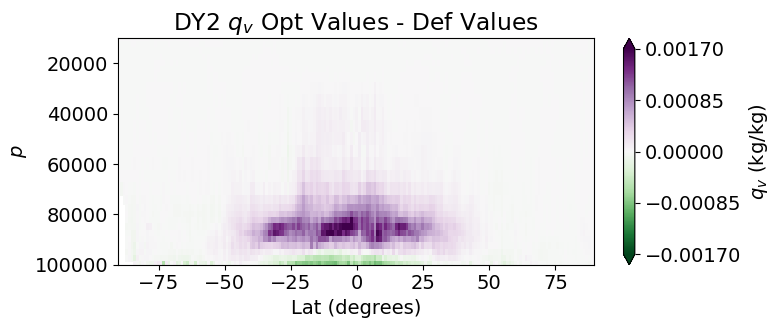

In [67]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY2_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY2_DEFAULT_RUN_DIR) + '/'
obs_file = 'DY2_era5_qv_ne30pg2.nc'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qv'].values
T_scream_def = ds_def['qv'].values
T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.0017, 0.0017)
plt.title(r'DY2 $q_v$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.0017, 0.0017, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_v$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY2qv_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()


/tmp/ipykernel_784037/3771976089.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/3771976089.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
/tmp/ipykernel_784037/3771976089.py:35: RuntimeWarning: Mean of empty slice
  T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))


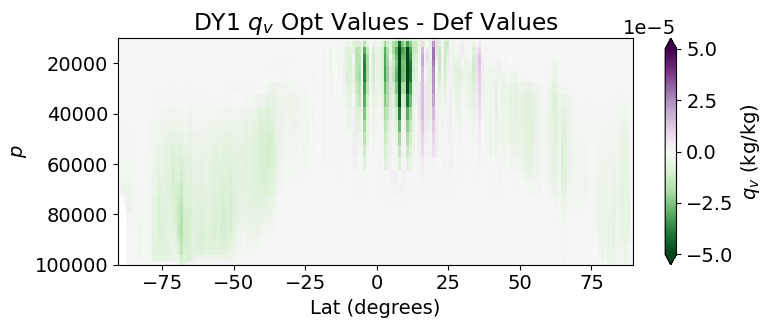

In [68]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY1_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY1_DEFAULT_RUN_DIR) + '/'
obs_file = 'DY1_era5_qv_ne30pg2.nc'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'

ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_sim['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qi'].values
T_scream_def = ds_def['qi'].values
#T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.00005, 0.00005)
#plt.clim(0, -0.017)
plt.title(r'DY1 $q_v$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
clb.set_label(r'$q_v$ (kg/kg)')
tick_locations = np.linspace(-0.00005, 0.00005, 5)
clb.set_ticks(tick_locations)
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY1qi_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()


/tmp/ipykernel_784037/3982445035.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/3982445035.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))


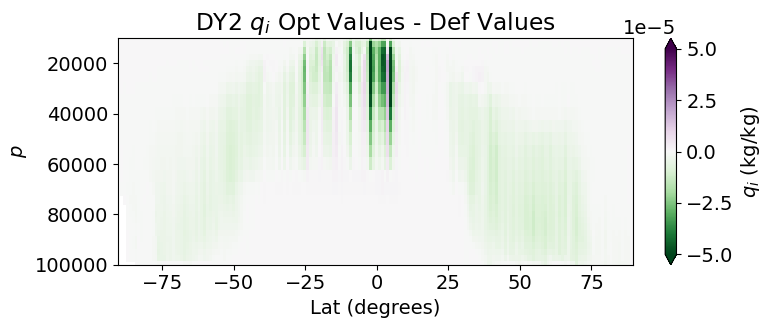

In [69]:
obs_dir = str(paths.DY1_OBS_DIR) + '/'
opt_dir = str(paths.DY2_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY2_DEFAULT_RUN_DIR) + '/'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'

#ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_opt['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qi'].values
T_scream_def = ds_def['qi'].values
#T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    #T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.00005, 0.00005)
plt.title(r'DY2 $q_i$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
clb.set_label(r'$q_i$ (kg/kg)')
tick_locations = np.linspace(-0.00005, 0.00005, 5)
clb.set_ticks(tick_locations)
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY2qi_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()


/tmp/ipykernel_784037/724793730.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/724793730.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))


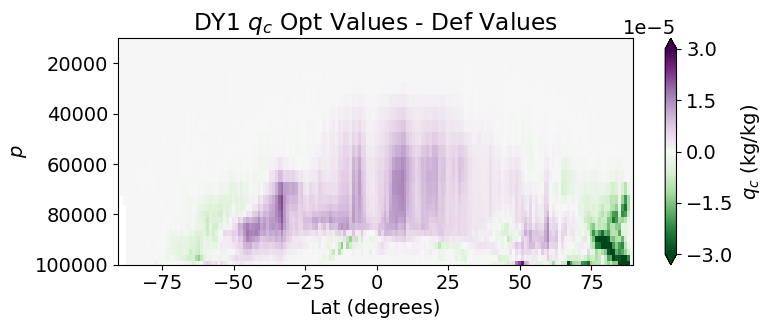

In [70]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY1_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY1_DEFAULT_RUN_DIR) + '/'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'

#ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_opt['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qc'].values
T_scream_def = ds_def['qc'].values
#T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    #T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.00003, 0.00003)
plt.title(r'DY1 $q_c$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.00003, 0.00003, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_c$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY1qc_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()


/tmp/ipykernel_784037/3852308215.py:33: RuntimeWarning: Mean of empty slice
  T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
/tmp/ipykernel_784037/3852308215.py:34: RuntimeWarning: Mean of empty slice
  T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))


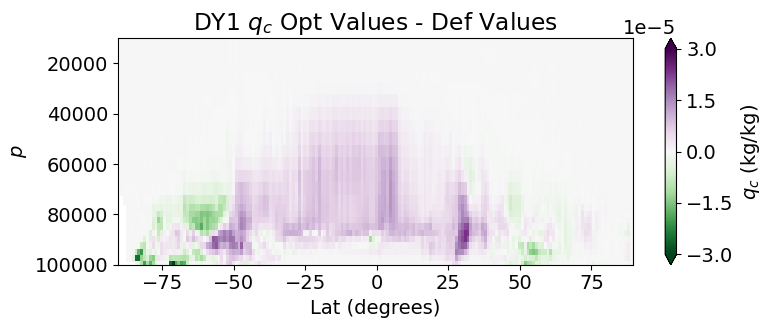

In [71]:
obs_dir = str(paths.OBS_DIR / 'other') + '/'
opt_dir = str(paths.DY2_OPTIMAL_RUN_DIR) + '/'
def_dir = str(paths.DY2_DEFAULT_RUN_DIR) + '/'
opt_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
def_file = 'output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'

#ds_obs = xr.open_mfdataset(obs_dir+obs_file)
ds_opt = xr.open_mfdataset(opt_dir+opt_file)
ds_def = xr.open_mfdataset(def_dir+def_file)

p = ds_opt['p_levs'].values #pressure values - need to look for (hecto)pascals here 

#T_scream = ds_sim['T_mid'].values #slice out first dimension
#T_obs = ds_obs['T'].values #might be hourly
T_scream_opt = ds_opt['qc'].values
T_scream_def = ds_def['qc'].values
#T_obs = ds_obs['Q'].values

lat = ds_obs['lat'].values
lat_bins = np.arange(-90,90,1)

lon = ds_obs['lon'].values

T_scream_opt_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_scream_def_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))
T_obs_rgr = np.zeros((len(lat_bins),len(T_scream[0,0,:])))

for i in range(len(lat_bins)-1):
    I = (lat < lat_bins[i+1]) & (lat > lat_bins[i])
    T_scream_opt_rgr[i,:] = np.nanmean(T_scream_opt[0,I,:],(0))
    T_scream_def_rgr[i,:] = np.nanmean(T_scream_def[0,I,:],(0))
    #T_obs_rgr[i,:] = np.nanmean(T_obs[:,:,I],(0,2))

size_1 = 4
size_2 = 3.5
fs = 14
fs_tick = 14 #default is 18
ms_size = 14
legend_font_size = 14
fig_number = 0
ll,pp = np.meshgrid(lat_bins,p,indexing='ij')

plt.figure(fig_number,(2*size_1,size_2))
plt.pcolor(ll,pp, T_scream_opt_rgr- T_scream_def_rgr, cmap='PRGn_r')
#plt.clim(-5,5)
plt.clim(-0.00003, 0.00003)
plt.title(r'DY1 $q_c$ Opt Values - Def Values')
clb = plt.colorbar(extend='both')
tick_locations = np.linspace(-0.00003, 0.00003, 5)
clb.set_ticks(tick_locations)
clb.set_label(r'$q_c$ (kg/kg)')
plt.xlabel('Lat (degrees)')
plt.ylabel(r'$p$')
plt.ylim(1e5,1e4)
plt.tick_params(labelsize=fs_tick);
#plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.rc('font', size=fs_tick)
plt.savefig(str(paths.FIGURES_DIR / 'curtain_plots') + '/'+'DY2qc_optdef_curtainplot.png', bbox_inches='tight', dpi=150)
plt.tight_layout()
